# Pick/ban rate vs Champion winrate

- Gráfico: Scatter plot (Gráfico de dispersión).
- Eje X: Frecuencia de aparición (Picks + Bans). Eje Y: Winrate.
- Insight: Los campeones en la esquina superior derecha son "OP" (Overpowered). Los de la inferior derecha son trampas (muy jugados pero pierden mucho).

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

# Data read

In [3]:
año = "2024"
df = pd.read_csv(f"../Data/Raw Data/{año}_LoL_esports_match_data_from_OraclesElixir.csv",low_memory=False)

In [4]:
# Mantener solo los jugadores (participantes 1-10)
df = df[df["participantid"].between(1, 10)]

In [5]:
# Frecuencia de aparición de cada campeón
apariciones = df["champion"].value_counts()

In [6]:
# Victorias por campeón
victorias = (
    df.groupby("champion")["result"]
      .sum()
)

In [7]:
# Crear DataFrame con ambas métricas
estadisticas = pd.DataFrame({
    "Apariciones": apariciones,
    "Victorias": victorias
}).fillna(0)

In [8]:
# Ordenar por frecuencia de aparición
estadisticas = estadisticas.sort_values(by="Apariciones", ascending=False)

# Posiciones del eje X
x = np.arange(len(estadisticas))

In [12]:
print(estadisticas)

          Apariciones  Victorias
champion                        
Rell             3834       2000
Nautilus         3828       1910
K'Sante          3773       1854
Varus            2685       1289
Corki            2512       1226
...               ...        ...
Rammus              6          2
Singed              6          2
Shaco               6          3
Teemo               3          1
Fizz                2          0

[168 rows x 2 columns]


In [13]:
estadisticas.to_csv("../Data/Statistics/champions_win_rate.csv")

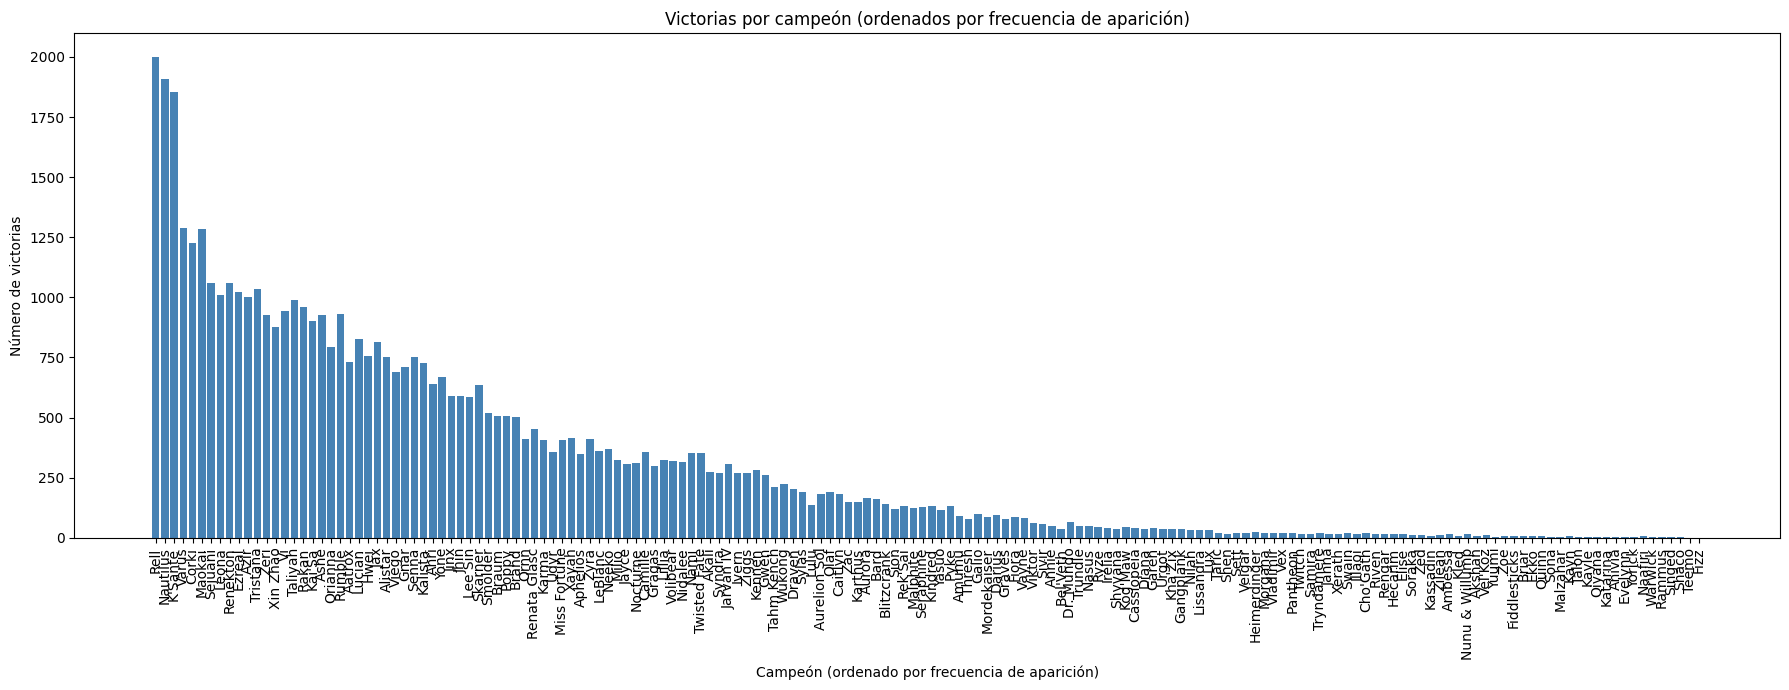

In [9]:
# Crear gráfico
plt.figure(figsize=(18,7))
plt.bar(x, estadisticas["Victorias"], color="steelblue")

plt.xticks(x, estadisticas.index, rotation=90)
plt.xlabel("Campeón (ordenado por frecuencia de aparición)")
plt.ylabel("Número de victorias")
plt.title("Victorias por campeón (ordenados por frecuencia de aparición)")

plt.tight_layout()
plt.show()

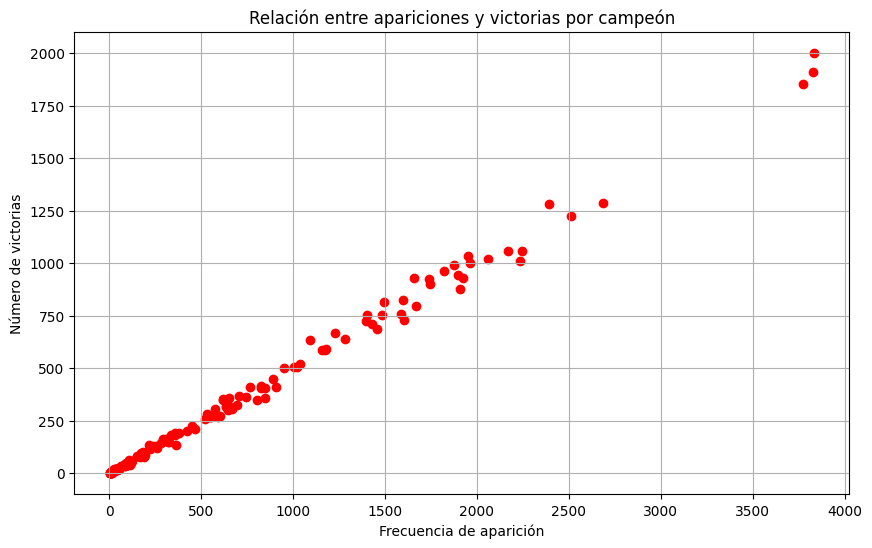

In [11]:
scatter_estadisticas = df.groupby("champion").agg(
    Apariciones=("champion", "count"),
    Victorias=("result", "sum")
)

plt.figure(figsize=(10,6))
plt.scatter(
    scatter_estadisticas["Apariciones"],
    scatter_estadisticas["Victorias"],
    color="red"
)

plt.xlabel("Frecuencia de aparición")
plt.ylabel("Número de victorias")
plt.title("Relación entre apariciones y victorias por campeón")
plt.grid(True)

plt.show()